<a href="https://colab.research.google.com/github/catchshashank/network-dynamics/blob/main/notebooks/status-network-updated-v150326.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Call Libraries
import scipy
import numpy as np
import matplotlib as plt
import pandas as pd
import sklearn

In [5]:
import os

# Define the base path to data
base_path = '/content/drive/MyDrive/SoundCloud'

# Read each file into its own DataFrame
affiliations = pd.read_stata(os.path.join(base_path, '12affiliations_sample.dta'))
comments = pd.read_stata(os.path.join(base_path, '12comments_sample.dta'))
favoritings = pd.read_stata(os.path.join(base_path, '12favoritings_sample.dta'))
messages = pd.read_stata(os.path.join(base_path, '12messages_sample.dta'))
reposts = pd.read_stata(os.path.join(base_path, '12reposts_sample.dta'))

In [6]:
users = pd.read_csv(os.path.join(base_path, 'user_ids.csv'))
users.head()

,Unnamed: 0,user_id,type,created_at
0,1,54849,creator,2009-01-01 00:47:08
1,2,54869,creator,2009-01-01 05:24:26
2,3,54882,creator,2009-01-01 09:28:54
3,4,54901,creator,2009-01-01 13:10:30
4,5,54912,creator,2009-01-01 14:20:57


In [7]:
creators_df = users[users['type'] == 'creator'].copy()
display(creators_df.head())
# Extract the creator IDs as a list or Series for use in functions
creators = creators_df['user_id'].unique()

,Unnamed: 0,user_id,type,created_at
0,1,54849,creator,2009-01-01 00:47:08
1,2,54869,creator,2009-01-01 05:24:26
2,3,54882,creator,2009-01-01 09:28:54
3,4,54901,creator,2009-01-01 13:10:30
4,5,54912,creator,2009-01-01 14:20:57


In [8]:
# Peek at Data
display(affiliations.head())
display(comments.head())
display(favoritings.head())
display(messages.head())
display(reposts.head())
display(creators_df.head())

,fan_id,contact_id,created_at
0,55250,45724,2009-01-02 15:14:42
1,55250,2629,2009-01-02 15:15:47
2,55250,4230,2009-01-02 15:15:56
3,55250,3082,2009-01-02 15:16:05
4,55250,3107,2009-01-02 15:16:13


,user_id,track_id,owner_id,created_at
0,56125,4912,274,2009-01-06 11:57:50
1,54181,116480,61390,2009-01-27 02:45:05
2,3983,125334,64864,2009-02-08 18:04:24
3,65739,140931,65739,2009-02-11 21:36:27
4,65739,140931,65739,2009-02-11 21:40:18


,user_id,track_id,owner_id,created_at
0,55806,98214,54084,2009-01-03 23:47:10
1,56588,100073,2153,2009-01-07 18:14:02
2,57524,103677,57276,2009-01-08 00:18:19
3,58048,58062,29763,2009-01-11 18:06:08
4,60584,55187,31543,2009-01-16 18:16:40


,sender_id,receiver_id,created_at
0,51272,55102,2009-01-02 22:43:33
1,54878,7915,2009-01-02 20:16:08
2,54878,7915,2009-01-04 21:58:29
3,54878,7915,2009-01-04 22:08:09
4,55013,52969,2009-01-03 03:35:42


,reposter_id,created_at,song_id,owner_id
0,194980,2012-06-07 11:52:27,48909076,80522
1,503949,2012-06-16 07:05:33,48718310,70917
2,194980,2012-06-17 16:01:50,49252926,80522
3,7564356,2012-07-02 21:44:03,7510652,84543
4,1762257,2012-07-04 16:22:40,43089879,61522


,Unnamed: 0,user_id,type,created_at
0,1,54849,creator,2009-01-01 00:47:08
1,2,54869,creator,2009-01-01 05:24:26
2,3,54882,creator,2009-01-01 09:28:54
3,4,54901,creator,2009-01-01 13:10:30
4,5,54912,creator,2009-01-01 14:20:57


#### **Define Parameters**
- Threshold = Cut-off for number of followers
- Window-Days = Days since influencer crosses threshold
- Top_K = Number of creators 'k' to be viewed

In [9]:
THRESHOLD = 100
WINDOW_DAYS = 180
TOP_K = 10

#### **Sorting Affiliations by timestamps**
- Clean the affiliations (follow) dataset.
- Keep only fan_id, contact_id, and created_at.
- Convert timestamps to datetime.
- Coerces IDs to numeric, remove missing values, sort by time, and drop duplicate follow edges.

**Output:** Time-ordered follower-following relationships.

In [10]:
def prep_affiliations(affiliations):
    a = affiliations[["fan_id", "contact_id", "created_at"]].copy()
    a["created_at"] = pd.to_datetime(a["created_at"], errors="coerce")
    a = a.dropna(subset=["fan_id", "contact_id", "created_at"])
    a["fan_id"] = pd.to_numeric(a["fan_id"], errors="coerce")
    a["contact_id"] = pd.to_numeric(a["contact_id"], errors="coerce")
    a = a.dropna(subset=["fan_id", "contact_id"])
    a = a.sort_values("created_at")
    a = a.drop_duplicates(subset=["fan_id", "contact_id"], keep="first")
    return a

display(prep_affiliations(affiliations))

,fan_id,contact_id,created_at
38480,54848,14730,2009-01-01 01:01:04
39220,54846,4610,2009-01-01 02:12:39
39221,54846,6281,2009-01-01 02:13:21
39222,54846,15386,2009-01-01 02:17:50
39223,54846,1214,2009-01-01 02:25:23
...,...,...,...
30493729,81303,83118585,2014-03-19 02:24:29
30673499,85286217,87783,2014-03-19 02:24:30
30673500,85286217,60663,2014-03-19 02:24:31
29822351,9348702,75620,2014-03-19 02:24:35


#### **Time-ordered list of creators**
- Computes when each creator reaches a follower threshold.
- Filters follow events to creators.
- Sorts follower arrivals chronologically.
- Assigns cumulative follower ranks per creator.
- Selects the timestamp when the rank equals the predefined threshold.

**Ouput:** Series mapping each creator to their threshold-crossing time.

In [11]:
def compute_tcross(a, creators):
    fe = a[a["contact_id"].isin(creators)].copy()
    fe = fe.sort_values(["contact_id", "created_at"])
    # Groups the DataFrame fe by each unique contact_id = applied independently to each creator)
    # Since cumcount() starts from 0, adding 1 makes the rank start from 1
    fe["rank"] = fe.groupby("contact_id").cumcount() + 1

    tcross = (
        fe[fe["rank"] == THRESHOLD]
        .set_index("contact_id")["created_at"]
    )
    # Explicitly assign the name "tcross" to the pd series
    tcross.name = "tcross"
    return tcross

display(compute_tcross(affiliations, creators))

,tcross
contact_id,
54846,2013-10-03 19:47:05
54847,2011-02-21 21:29:14
54861,2010-11-11 22:03:31
54866,2012-06-08 02:03:49
54869,2013-10-16 21:07:56
...,...
93702,2011-09-28 20:08:51
93703,2009-12-13 05:19:28
93705,2010-07-01 08:53:52


#### **Compute Reciprocal Ties**
- Identifies reciprocal (mutual) follow ties among creators.
- Extract directed follow edges
- Filter them to creator–creator relationships
- Perform a *self-merge* with reversed edges to retain only pairs where both users follow each other.

**Output:** Produce a clean set of reciprocal strong-tie candidates.

In [12]:
def reciprocal_ties(a, creators):
    # Extracts directed follow edges from the affiliations dataset
    edges = a[["fan_id", "contact_id"]].copy()
    # Renames as a directed edge u → v
    edges = edges.rename(columns={"fan_id": "u", "contact_id": "v"})
    # Filter analysis to keep creator–creator relationships
    edges = edges[
        edges["u"].isin(creators) &
        edges["v"].isin(creators)
    ]

    # Strong ties: Match each edge with its reversed counterpart (v → u)
    recip = edges.merge(
        edges.rename(columns={"u": "v", "v": "u"}),
        on=["u", "v"],
        how="inner"
    )
    # Reciprocal ties are bidirected since both u and v follow each other
    return recip.drop_duplicates()

display(reciprocal_ties(affiliations, creators))

,u,v
0,56775,57376
1,57572,58696
2,59096,59531
3,59763,58817
4,60338,56788
...,...,...
44039,77934,69675
44040,69905,75684
44041,70183,84083
44042,60882,80245


**Checking for distinct creators in each column**

In [13]:
recip_df = reciprocal_ties(affiliations, creators)

distinct_u_count = recip_df['u'].nunique()
distinct_v_count = recip_df['v'].nunique()

print(f"Distinct count in 'u' column: {distinct_u_count}")
print(f"Distinct count in 'v' column: {distinct_v_count}")

Distinct count in 'u' column: 8828
Distinct count in 'v' column: 8828


This visualization shows the network of reciprocal ties. Each dot (node) represents a creator, and each line (edge) represents a mutual following relationship. Denser areas indicate creators who are part of more interconnected groups of strong ties. Due to the large number of creators, individual labels are suppressed to keep the visualization clear.

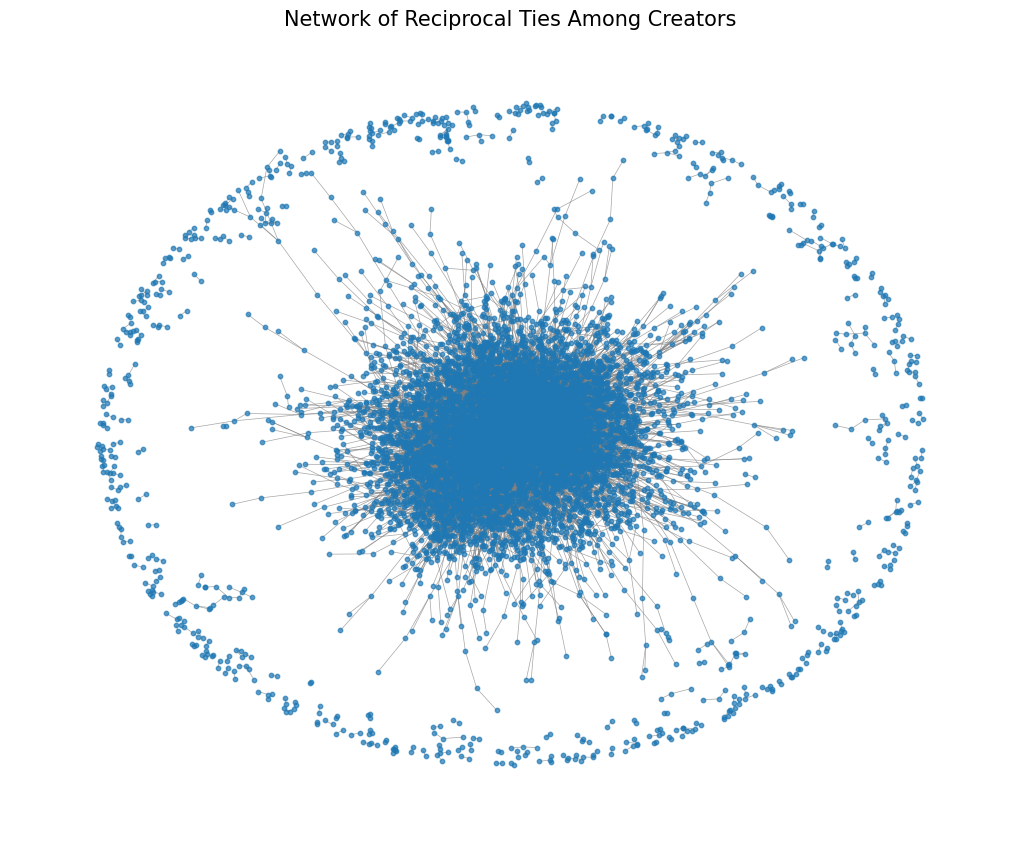

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a graph from the reciprocal ties DataFrame
G = nx.from_pandas_edgelist(recip_df, 'u', 'v', create_using=nx.Graph)

# Visualize the graph
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.1) # Use spring layout for better visualization of clusters
nx.draw(G, pos, with_labels=False, node_size=10, width=0.5, alpha=0.7, edge_color='gray')
plt.title('Network of Reciprocal Ties Among Creators', size=15)
plt.show()

####**Sort, clean, merge, and classify each interaction type by source and target**
- Convert timestamps, remove missing or invalid IDs.
- Excludes self-interactions.
- Rename columns to a consistent source–target format.
- Concatenate both datasets.

**Output:** Single time-ordered interaction table for tie-intensity analysis.

In [14]:
def build_interactions(comments, favoritings, messages, reposts):
    def clean(df, interaction_type):
        df = df[["user_id", "owner_id", "created_at"]].copy()
        df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
        df = df.dropna(subset=["user_id", "owner_id", "created_at"])
        # Coercing values in the df in "user_id" and "owner_id" to be numeric
        df["user_id"] = pd.to_numeric(df["user_id"], errors="coerce")
        df["owner_id"] = pd.to_numeric(df["owner_id"], errors="coerce")
        df = df.dropna(subset=["user_id", "owner_id"])
        # Remove self-interactions
        df = df[df["user_id"] != df["owner_id"]]
        df = df.rename(columns={
            "user_id": "source",
            "owner_id": "target",
            "created_at": "time"
        })
        df['interaction_type'] = interaction_type # Add a column for interaction type
        return df

    interactions = pd.concat([
        clean(comments, 'comment'),
        clean(favoritings, 'favoriting'),
        clean(messages.rename(columns={"sender_id": "user_id", "receiver_id": "owner_id"}), 'message'),
        clean(reposts.rename(columns={"reposter_id": "user_id"}), 'repost')
    ], ignore_index=True)
    return interactions.sort_values(["source", "time"])

display(build_interactions(comments, favoritings, messages, reposts))

,source,target,time,interaction_type
14699112,2,56061,2009-01-08 19:37:05,message
13522359,2,92292,2009-04-02 15:08:39,message
14579610,2,77676,2009-05-17 01:18:06,message
3042122,2,76216,2011-02-19 14:35:09,favoriting
3042130,2,76216,2011-02-19 18:23:13,favoriting
...,...,...,...,...
17056476,94461189,60663,2014-05-13 22:41:05,repost
17056477,94461189,60663,2014-05-13 22:43:40,repost
16926425,94463435,81166,2014-05-13 22:56:42,repost
16987437,94466307,67248,2014-05-13 23:19:51,repost


**Why we merge only "u" on "contact_id" and not "v" as well?**
- **Symmetry:** If u is in a reciprocal tie with v (meaning (u, v) is in recip_df), then v is also in a reciprocal tie with u (meaning (v, u) is also implicitly, or explicitly as another row, part of the reciprocal set.
- Because of this symmetry, any creator that appears in the 'u' column (as someone initiating a mutual follow) must also appear in the 'v' column (as someone being mutually followed by another creator).
- Conversely, any creator in the 'v' column must also be in the 'u' column. Therefore, the set of unique creators in the 'u' column is precisely the same as the set of unique creators in the 'v' column, leading to identical distinct counts.

In [15]:
def intensity_pre_post(interactions, recip, tcross):

    # Keep only creators who crossed threshold
    crossed = tcross.index
    recip = recip[recip["u"].isin(crossed)].copy()

    # Attach tcross to edges
    recip = recip.merge(
        tcross.reset_index(),
        left_on="u",
        right_on="contact_id",
        how="inner"
    ).rename(columns={"contact_id": "creator_id"})

    # The tcross column should already be datetime from compute_tcross and prep_affiliations.
    # Remove dayfirst=True as it's causing incorrect parsing for YYYY-MM-DD format.
    recip["tcross"] = pd.to_datetime(recip["tcross"])
    recip["post_end"] = recip["tcross"] + pd.Timedelta(days=WINDOW_DAYS)

    # Match interactions along reciprocal edges
    ev = interactions.merge(
        recip[["u", "v", "tcross", "post_end"]],
        left_on=["source", "target"],
        right_on=["u", "v"],
        how="inner"
    )

    # Ensure interaction times are also datetime for comparison
    # Remove dayfirst=True for consistency with YYYY-MM-DD format.
    ev["time"] = pd.to_datetime(ev["time"])

    pre = ev["time"] < ev["tcross"]
    post = (ev["time"] >= ev["tcross"]) & (ev["time"] <= ev["post_end"])

    ev = ev[pre | post].copy()
    ev["window"] = np.where(pre.loc[ev.index], "pre", "post")

    pre_counts = (
        ev[ev["window"] == "pre"]
        .groupby(["u", "v", "interaction_type"])
        .size()
        .rename("intensity_pre")
    )

    post_counts = (
        ev[ev["window"] == "post"]
        .groupby(["u", "v", "interaction_type"])
        .size()
        .rename("intensity_post")
    )

    out = pd.concat([pre_counts, post_counts], axis=1).fillna(0).reset_index()

    return out

display(intensity_pre_post(build_interactions(comments, favoritings, messages, reposts), reciprocal_ties(affiliations, creators), compute_tcross(affiliations, creators)))

,u,v,interaction_type,intensity_pre,intensity_post
0,54869,77381,comment,10.0,0.0
1,54869,77381,favoriting,7.0,6.0
2,54880,81070,favoriting,1.0,0.0
3,54881,76440,comment,1.0,0.0
4,54883,69958,comment,2.0,2.0
...,...,...,...,...,...
7946,93557,58723,message,0.0,1.0
7947,93557,64135,comment,0.0,1.0
7948,93580,57431,message,0.0,1.0
7949,93635,74403,favoriting,0.0,2.0


In [16]:
interactions_df = build_interactions(comments, favoritings, messages, reposts)
recip_df = reciprocal_ties(affiliations, creators)
tcross_df = compute_tcross(affiliations, creators)
intensity_data = intensity_pre_post(interactions_df, recip_df, tcross_df)

# Aggregate interaction_type to get total intensities per reciprocal tie (u,v)
intensity_data_agg = intensity_data.groupby(['u', 'v']).agg(
    intensity_pre=('intensity_pre', 'sum'),
    intensity_post=('intensity_post', 'sum')
).reset_index()

print("Combined Interaction Types per Reciprocal Tie (Pre vs Post):")
display(intensity_data_agg.head())

Combined Interaction Types per Reciprocal Tie (Pre vs Post):


,u,v,intensity_pre,intensity_post
0,54869,77381,17.0,6.0
1,54878,60682,0.0,3.0
2,54880,77321,0.0,3.0
3,54880,81070,1.0,0.0
4,54880,84104,0.0,1.0


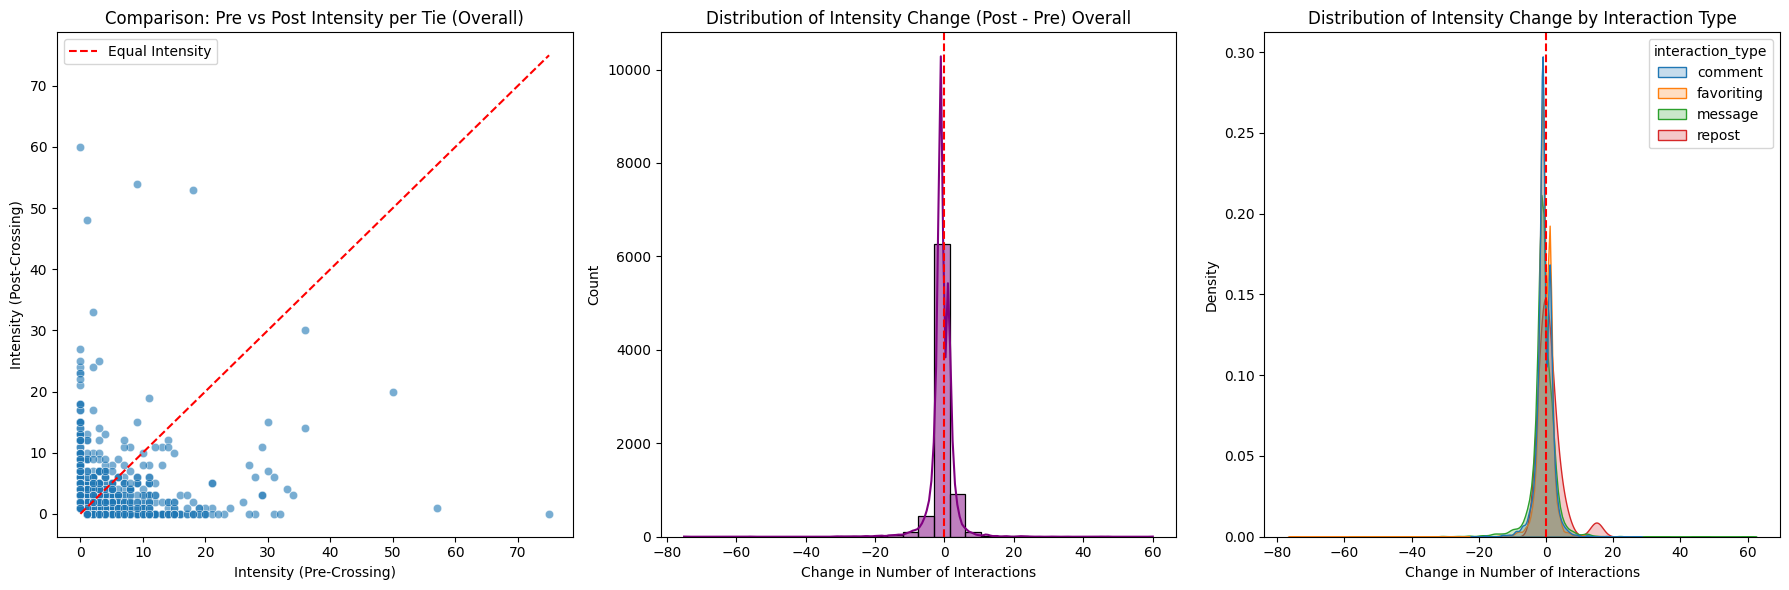

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the intensity data
interactions_df = build_interactions(comments, favoritings, messages, reposts)
recip_df = reciprocal_ties(affiliations, creators)
tcross_df = compute_tcross(affiliations, creators)
intensity_data = intensity_pre_post(interactions_df, recip_df, tcross_df)

# Create the visualization
plt.figure(figsize=(18, 6)) # Increased figure size to accommodate more plots

# Subplot 1: Scatter plot of Pre vs Post intensity (overall)
plt.subplot(1, 3, 1) # Changed to 1 row, 3 columns
sns.scatterplot(data=intensity_data, x='intensity_pre', y='intensity_post', alpha=0.6)
plt.plot([0, intensity_data['intensity_pre'].max()], [0, intensity_data['intensity_pre'].max()], 'r--', label='Equal Intensity')
plt.title('Comparison: Pre vs Post Intensity per Tie (Overall)')
plt.xlabel('Intensity (Pre-Crossing)')
plt.ylabel('Intensity (Post-Crossing)')
plt.legend()

# Subplot 2: Distribution of changes (overall)
plt.subplot(1, 3, 2) # Changed to 1 row, 3 columns
intensity_data['change'] = intensity_data['intensity_post'] - intensity_data['intensity_pre']
sns.histplot(intensity_data['change'], bins=30, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Intensity Change (Post - Pre) Overall')
plt.xlabel('Change in Number of Interactions')

# Subplot 3: Distribution of changes by interaction type
plt.subplot(1, 3, 3) # Added a new subplot
sns.kdeplot(data=intensity_data, x='change', hue='interaction_type', fill=True, common_norm=False)
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Intensity Change by Interaction Type')
plt.xlabel('Change in Number of Interactions')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

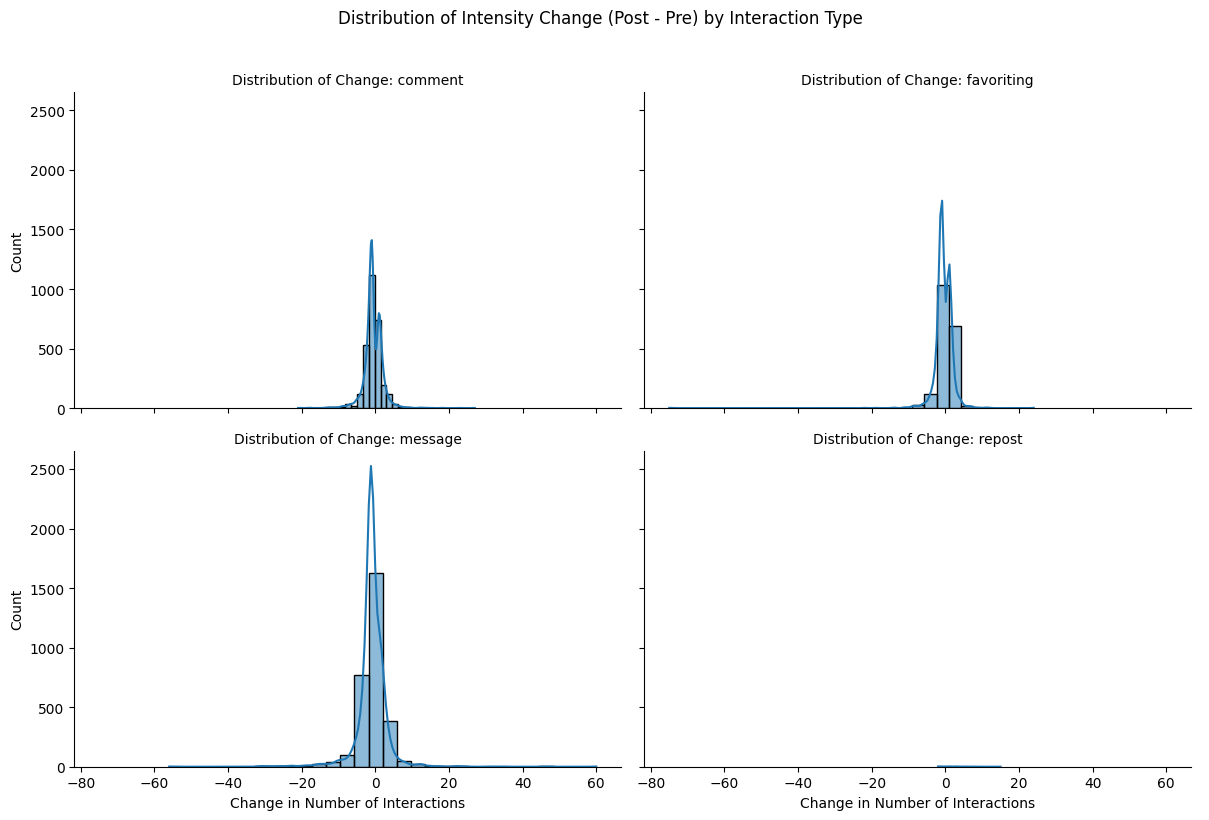

In [18]:
# Recalculate intensity_data and add 'change' column if not already present
# (Ensuring data is fresh in case previous cell wasn't run again)
interactions_df = build_interactions(comments, favoritings, messages, reposts)
recip_df = reciprocal_ties(affiliations, creators)
tcross_df = compute_tcross(affiliations, creators)
intensity_data = intensity_pre_post(interactions_df, recip_df, tcross_df)
intensity_data['change'] = intensity_data['intensity_post'] - intensity_data['intensity_pre']

# Create a FacetGrid to plot the distribution of change for each interaction type separately
g = sns.FacetGrid(intensity_data, col='interaction_type', col_wrap=2, height=4, aspect=1.5)
g.map(sns.histplot, 'change', bins=30, kde=True)
g.set_axis_labels('Change in Number of Interactions', 'Count')
g.set_titles('Distribution of Change: {col_name}')
g.add_legend()
plt.suptitle('Distribution of Intensity Change (Post - Pre) by Interaction Type', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()

This set of plots focuses on each interaction type (comment, favoriting, message, repost), showing how the number of interactions changed from the pre-crossing to the post-crossing period. The red vertical dashed line at 0 helps to quickly identify if the interactions generally increased, decreased, or remained stable for that specific type.

####**Interaction Switching Metric**

In [17]:
def interaction_switching_metrics(interactions, tcross, min_pre_partners=0):

    # Keep only creators who crossed threshold
    crossed = tcross.index
    ev = interactions[interactions["source"].isin(crossed)].copy()

    # Attach creator’s tcross to their interaction rows
    ev = ev.merge(
        tcross.reset_index(),
        left_on="source",
        right_on="contact_id",
        how="inner"
    )

    # Parse interaction and crossing timestamps
    # Remove dayfirst=True as it's causing incorrect parsing for YYYY-MM-DD format.
    ev["time"] = pd.to_datetime(ev["time"])
    ev["tcross"] = pd.to_datetime(ev["tcross"])

    # Label each interaction as pre/post crossing.
    ev["window"] = np.where(ev["time"] < ev["tcross"], "pre", "post")

    results = []

    for u, g in ev.groupby("source"):

        pre_partners = set(g[g["window"] == "pre"]["target"])
        post_partners = set(g[g["window"] == "post"]["target"])

        if len(pre_partners) < min_pre_partners:
            continue

        # Forms all partners
        union = pre_partners.union(post_partners)
        # Forms repeated partners
        intersection = pre_partners.intersection(post_partners)

        # Stability: overlap divided by union
        jaccard = len(intersection) / len(union) if len(union) > 0 else np.nan

        # Switching: new post-only partners divided by post partners
        new_share = len(post_partners - pre_partners) / len(post_partners) if len(post_partners) > 0 else np.nan

        results.append({
            "creator_id": u,
            "n_pre_partners": len(pre_partners),
            "n_post_partners": len(post_partners),
            "jaccard_similarity": jaccard,
            "new_partner_share": new_share
        })

    return pd.DataFrame(results)

display(interaction_switching_metrics(build_interactions(comments, favoritings, messages, reposts), compute_tcross(affiliations, creators)))

,creator_id,n_pre_partners,n_post_partners,jaccard_similarity,new_partner_share
0,54846,33,6,0.026316,0.833333
1,54847,4,21,0.000000,1.000000
2,54861,18,6,0.000000,1.000000
3,54866,2,1,0.000000,1.000000
4,54869,117,31,0.064748,0.709677
...,...,...,...,...,...
8616,93702,7,8,0.071429,0.875000
8617,93703,0,4,0.000000,1.000000
8618,93705,4,17,0.000000,1.000000
8619,93712,10,187,0.005102,0.994652


Plot interpretation:
1. **Jaccard Similarity** = ∣ Pre ∩ Post ∣ / ∣ Pre ∪ Post ∣
    - 1 → same partners
    - 0 → completely different partners

After crossing the follower (n = 100) threshold:
  - Creators are interacting with largely different creators.
  - Partner switching is strong.
  - Status transition → reallocation of social attention

2. **New Partner Share** = | Post - Pre | ​/ | Post |
    - 1 → all post partners are new
    - 0 → no new partners

After crossing the follower (n = 100) threshold:
- Creators overwhelmingly interact with new creators.
- Post-threshold interactions are largely not with prior partners.
- This strongly supports a status-driven social expansion or redirection effect.

#### **Interaction Intensity screened by date of reciprocal ties**
Calculate the reciprocal tie establishment date for each pair in the `recip_df` by finding the later of the two individual follow dates from the preprocessed `affiliations` data, then merge these dates into the `intensity_data`.

In [18]:
cleaned_affiliations = prep_affiliations(affiliations)
print("Cleaned affiliations DataFrame:")
display(cleaned_affiliations)

Cleaned affiliations DataFrame:


,fan_id,contact_id,created_at
38480,54848,14730,2009-01-01 01:01:04
39220,54846,4610,2009-01-01 02:12:39
39221,54846,6281,2009-01-01 02:13:21
39222,54846,15386,2009-01-01 02:17:50
39223,54846,1214,2009-01-01 02:25:23
...,...,...,...
30493729,81303,83118585,2014-03-19 02:24:29
30673499,85286217,87783,2014-03-19 02:24:30
30673500,85286217,60663,2014-03-19 02:24:31
29822351,9348702,75620,2014-03-19 02:24:35


In [19]:
merged_u_v = recip_df.merge(
    cleaned_affiliations[['fan_id', 'contact_id', 'created_at']],
    left_on=['u', 'v'],
    right_on=['fan_id', 'contact_id'],
    how='inner'
).rename(columns={'created_at': 'u_follows_v_at'})

merged_u_v_v_u = merged_u_v.merge(
    cleaned_affiliations[['fan_id', 'contact_id', 'created_at']],
    left_on=['v', 'u'],
    right_on=['fan_id', 'contact_id'],
    how='inner',
    suffixes=('_u_v', '_v_u')
).rename(columns={'created_at': 'v_follows_u_at'})

display(merged_u_v_v_u.head())

,u,v,fan_id_u_v,contact_id_u_v,u_follows_v_at,fan_id_v_u,contact_id_v_u,v_follows_u_at
0,56775,57376,56775,57376,2009-01-07 18:45:34,57376,56775,2009-01-07 18:53:14
1,57572,58696,57572,58696,2009-01-12 08:24:28,58696,57572,2009-01-11 18:24:36
2,59096,59531,59096,59531,2009-01-13 20:40:19,59531,59096,2009-01-13 20:38:56
3,59763,58817,59763,58817,2009-01-14 11:18:59,58817,59763,2009-01-16 22:11:05
4,60338,56788,60338,56788,2009-01-19 12:17:01,56788,60338,2009-01-19 12:11:57


In [20]:
merged_u_v_v_u['tie_established_on'] = merged_u_v_v_u[['u_follows_v_at', 'v_follows_u_at']].max(axis=1)

tie_establishment_dates = merged_u_v_v_u[['u', 'v', 'tie_established_on']].copy()

print("Tie Establishment Dates DataFrame:")
display(tie_establishment_dates)

Tie Establishment Dates DataFrame:


,u,v,tie_established_on
0,56775,57376,2009-01-07 18:53:14
1,57572,58696,2009-01-12 08:24:28
2,59096,59531,2009-01-13 20:40:19
3,59763,58817,2009-01-16 22:11:05
4,60338,56788,2009-01-19 12:17:01
...,...,...,...
44039,77934,69675,2014-03-15 23:31:36
44040,69905,75684,2014-03-18 09:51:34
44041,70183,84083,2014-03-11 23:00:22
44042,60882,80245,2014-03-13 14:59:50


In [21]:
intensity_data = intensity_data.merge(
    tie_establishment_dates,
    on=['u', 'v'],
    how='left'
)

print("Updated intensity_data DataFrame with 'tie_established_on':")
display(intensity_data.head())

Updated intensity_data DataFrame with 'tie_established_on':


,u,v,interaction_type,intensity_pre,intensity_post,tie_established_on
0,54869,77381,comment,10.0,0.0,2013-09-04 10:48:30
1,54869,77381,favoriting,7.0,6.0,2013-09-04 10:48:30
2,54880,81070,favoriting,1.0,0.0,2010-03-24 05:35:45
3,54881,76440,comment,1.0,0.0,2010-09-10 13:07:35
4,54883,69958,comment,2.0,2.0,2011-08-13 12:48:18


In [22]:
interactions_df = build_interactions(comments, favoritings, messages, reposts)
recip_df = reciprocal_ties(affiliations, creators)
tcross_df = compute_tcross(affiliations, creators)
intensity_data = intensity_pre_post(interactions_df, recip_df, tcross_df)
intensity_data['change'] = intensity_data['intensity_post'] - intensity_data['intensity_pre']

intensity_data = intensity_data.merge(
    tie_establishment_dates,
    on=['u', 'v'],
    how='left'
)

print("Updated intensity_data DataFrame with 'tie_established_on':")
display(intensity_data.head())

Updated intensity_data DataFrame with 'tie_established_on':


,u,v,interaction_type,intensity_pre,intensity_post,change,tie_established_on
0,54869,77381,comment,10.0,0.0,-10.0,2013-09-04 10:48:30
1,54869,77381,favoriting,7.0,6.0,-1.0,2013-09-04 10:48:30
2,54880,81070,favoriting,1.0,0.0,-1.0,2010-03-24 05:35:45
3,54881,76440,comment,1.0,0.0,-1.0,2010-09-10 13:07:35
4,54883,69958,comment,2.0,2.0,0.0,2011-08-13 12:48:18


#### **Interaction Intensity before and after establishment of reciprocal tie**
- Use the `tie_established_on` date as the reference point.

In [23]:
def intensity_pre_post_tie_established(interactions, tie_establishment_dates, window_days):
    # a. Merge the interactions DataFrame with the tie_establishment_dates DataFrame
    # The instruction specifies merging on ['source', 'target'] and ['u', 'v']
    merged_interactions = interactions.merge(
        tie_establishment_dates,
        left_on=['source', 'target'],
        right_on=['u', 'v'],
        how='inner'
    )

    # b. Convert the 'time' column in merged_interactions and 'tie_established_on' to datetime objects.
    # 'time' should already be datetime from build_interactions, but ensure it here.
    merged_interactions['time'] = pd.to_datetime(merged_interactions['time'], errors='coerce')
    merged_interactions['tie_established_on'] = pd.to_datetime(merged_interactions['tie_established_on'], errors='coerce')

    # Drop rows where datetime conversion failed
    merged_interactions = merged_interactions.dropna(subset=['time', 'tie_established_on'])

    # Calculate window boundaries
    merged_interactions['pre_start_boundary'] = merged_interactions['tie_established_on'] - pd.Timedelta(days=window_days)
    merged_interactions['post_end_boundary'] = merged_interactions['tie_established_on'] + pd.Timedelta(days=window_days)

    # c. Define the 'pre' window
    pre_condition = (
        (merged_interactions['time'] >= merged_interactions['pre_start_boundary']) &
        (merged_interactions['time'] < merged_interactions['tie_established_on'])
    )

    # d. Define the 'post' window
    post_condition = (
        (merged_interactions['time'] >= merged_interactions['tie_established_on']) &
        (merged_interactions['time'] <= merged_interactions['post_end_boundary'])
    )

    # e. Filter to include only interactions that fall within either the 'pre' or 'post' window.
    filtered_interactions = merged_interactions[pre_condition | post_condition].copy()

    # f. Create a new column named 'window'
    filtered_interactions['window'] = np.where(pre_condition.loc[filtered_interactions.index], 'pre', 'post')

    # g. Group by 'u', 'v', and 'interaction_type', and count the number of interactions
    pre_counts = (
        filtered_interactions[filtered_interactions['window'] == 'pre']
        .groupby(['u', 'v', 'interaction_type'])
        .size()
        .rename('intensity_pre_tie')
    )

    post_counts = (
        filtered_interactions[filtered_interactions['window'] == 'post']
        .groupby(['u', 'v', 'interaction_type'])
        .size()
        .rename('intensity_post_tie')
    )

    # h. Concatenate pre and post counts, filling any missing values with 0.0.
    # Using outer join to ensure all combinations of (u, v, interaction_type) are present
    # even if they only have pre or post interactions.
    result = pd.concat([pre_counts, post_counts], axis=1).fillna(0.0)

    # i. Reset the index of the resulting DataFrame and return it.
    return result.reset_index()

# 2. Call the intensity_pre_post_tie_established function
intensity_by_tie_dates = intensity_pre_post_tie_established(
    interactions=interactions_df,
    tie_establishment_dates=tie_establishment_dates,
    window_days=WINDOW_DAYS
)

# 3. Display the first few rows of intensity_by_tie_dates
print("Intensity by Tie Establishment Dates:")
display(intensity_by_tie_dates.head())

Intensity by Tie Establishment Dates:


,u,v,interaction_type,intensity_pre_tie,intensity_post_tie
0,54869,77381,comment,8.0,0.0
1,54869,77381,favoriting,7.0,6.0
2,54878,60682,message,1.0,1.0
3,54878,66122,message,2.0,0.0
4,54880,77705,comment,1.0,0.0


In [24]:
import pandas as pd

# Aggregate intensity_by_tie_dates to get total intensities per reciprocal tie (u,v)
intensity_by_tie_dates_agg = intensity_by_tie_dates.groupby(['u', 'v']).agg(
    intensity_pre_tie=('intensity_pre_tie', 'sum'),
    intensity_post_tie=('intensity_post_tie', 'sum')
).reset_index()

# Ensure the 'change' column is calculated for the aggregated data
intensity_by_tie_dates_agg['change'] = intensity_by_tie_dates_agg['intensity_post_tie'] - intensity_by_tie_dates_agg['intensity_pre_tie']

# 1. Merge with tie_establishment_dates to get 'tie_established_on'
intensity_by_tie_dates_agg = intensity_by_tie_dates_agg.merge(
    tie_establishment_dates[['u', 'v', 'tie_established_on']],
    on=['u', 'v'],
    how='left'
)

# 2. Calculate the first interaction time for each (u,v) pair
#    Assuming tie_establishment_dates_symmetric is already available globally from previous steps.
first_interaction_times = interactions_df.merge(
    tie_establishment_dates,
    left_on=['source', 'target'],
    right_on=['u', 'v'],
    how='inner'
).groupby(['u', 'v'])['time'].min().reset_index()

first_interaction_times = first_interaction_times.rename(columns={
    'u': 'u',
    'v': 'v',
    'time': 'first_interaction_time'
})

# Merge first_interaction_times into intensity_by_tie_dates_agg
intensity_by_tie_dates_agg = intensity_by_tie_dates_agg.merge(
    first_interaction_times,
    on=['u', 'v'],
    how='left'
)

print("Aggregated Intensity by Tie Establishment Dates (with Tie Establishment and First Interaction Times):")
display(intensity_by_tie_dates_agg)

Aggregated Intensity by Tie Establishment Dates (with Tie Establishment and First Interaction Times):


,u,v,intensity_pre_tie,intensity_post_tie,change,tie_established_on,first_interaction_time
0,54869,77381,15.0,6.0,-9.0,2013-09-04 10:48:30,2012-01-08 17:42:15
1,54878,60682,1.0,2.0,1.0,2010-10-06 05:50:33,2010-07-10 04:35:03
2,54878,66122,2.0,0.0,-2.0,2013-03-17 21:22:02,2013-03-11 02:53:00
3,54878,87331,0.0,1.0,1.0,2012-06-15 00:45:46,2012-06-15 00:46:07
4,54880,55642,0.0,5.0,5.0,2011-01-18 00:34:17,2011-02-22 21:48:07
...,...,...,...,...,...,...,...
7579,93676,93580,0.0,1.0,1.0,2012-08-21 17:12:56,2012-08-30 14:11:17
7580,93699,74598,1.0,0.0,-1.0,2010-11-07 10:29:50,2010-11-07 10:29:33
7581,93703,88592,1.0,0.0,-1.0,2014-01-26 16:57:25,2013-11-01 13:06:02
7582,93705,93005,0.0,1.0,1.0,2009-04-08 21:14:37,2009-04-12 06:26:08


In [25]:
def interaction_switching_metrics_tie_estab(interactions, tie_establishment_dates, window_days, min_pre_partners=0):

    ev = interactions.copy()

    # First, let's gather all tie establishment dates associated with each creator, either as 'u' or 'v'
    creator_tie_dates_u = tie_establishment_dates[['u', 'tie_established_on']].rename(columns={'u': 'creator_id'})
    creator_tie_dates_v = tie_establishment_dates[['v', 'tie_established_on']].rename(columns={'v': 'creator_id'})

    all_creator_tie_dates = pd.concat([creator_tie_dates_u, creator_tie_dates_v])

    # Find the earliest tie establishment date for each creator
    earliest_tie_established_on = all_creator_tie_dates.groupby('creator_id')['tie_established_on'].min().reset_index()
    earliest_tie_established_on.rename(columns={'tie_established_on': 'reference_date'}, inplace=True)

    # Attach creator's earliest reference_date to their interaction rows
    ev = ev.merge(
        earliest_tie_established_on,
        left_on="source",
        right_on="creator_id",
        how="inner"
    )

    # Parse interaction and reference timestamps
    ev["time"] = pd.to_datetime(ev["time"], errors="coerce")
    ev["reference_date"] = pd.to_datetime(ev["reference_date"], errors="coerce")
    ev = ev.dropna(subset=["time", "reference_date"])

    # Define window boundaries
    ev["pre_start_boundary"] = ev["reference_date"] - pd.Timedelta(days=window_days)
    ev["post_end_boundary"] = ev["reference_date"] + pd.Timedelta(days=window_days)

    # Label each interaction as pre/post crossing based on reference_date
    pre_condition = (
        (ev["time"] >= ev["pre_start_boundary"]) &
        (ev["time"] < ev["reference_date"])
    )

    post_condition = (
        (ev["time"] >= ev["reference_date"]) &
        (ev["time"] <= ev["post_end_boundary"])
    )

    # Filter to include only interactions that fall within either the 'pre' or 'post' window.
    filtered_ev = ev[pre_condition | post_condition].copy()

    filtered_ev["window"] = np.where(pre_condition.loc[filtered_ev.index], "pre", "post")

    results = []

    for u, g in filtered_ev.groupby("source"):

        pre_partners = set(g[g["window"] == "pre"]["target"])
        post_partners = set(g[g["window"] == "post"]["target"])

        if len(pre_partners) < min_pre_partners:
            continue

        # Forms all partners
        union = pre_partners.union(post_partners)
        # Forms repeated partners
        intersection = pre_partners.intersection(post_partners)

        # Stability: overlap divided by union
        jaccard = len(intersection) / len(union) if len(union) > 0 else np.nan

        # Switching: new post-only partners divided by post partners
        new_share = len(post_partners - pre_partners) / len(post_partners) if len(post_partners) > 0 else np.nan

        results.append({
            "creator_id": u,
            "n_pre_partners": len(pre_partners),
            "n_post_partners": len(post_partners),
            "jaccard_similarity": jaccard,
            "new_partner_share": new_share
        })

    return pd.DataFrame(results)

# Call the updated function with appropriate arguments
display(interaction_switching_metrics_tie_estab(interactions_df, tie_establishment_dates, WINDOW_DAYS))

,creator_id,n_pre_partners,n_post_partners,jaccard_similarity,new_partner_share
0,54846,6,3,0.285714,0.333333
1,54861,3,4,0.000000,1.000000
2,54866,1,0,0.000000,NaN
3,54869,44,43,0.144737,0.744186
4,54874,0,5,0.000000,1.000000
...,...,...,...,...,...
7628,93699,7,3,0.000000,1.000000
7629,93702,1,2,0.000000,1.000000
7630,93703,3,0,0.000000,NaN
7631,93705,0,2,0.000000,1.000000


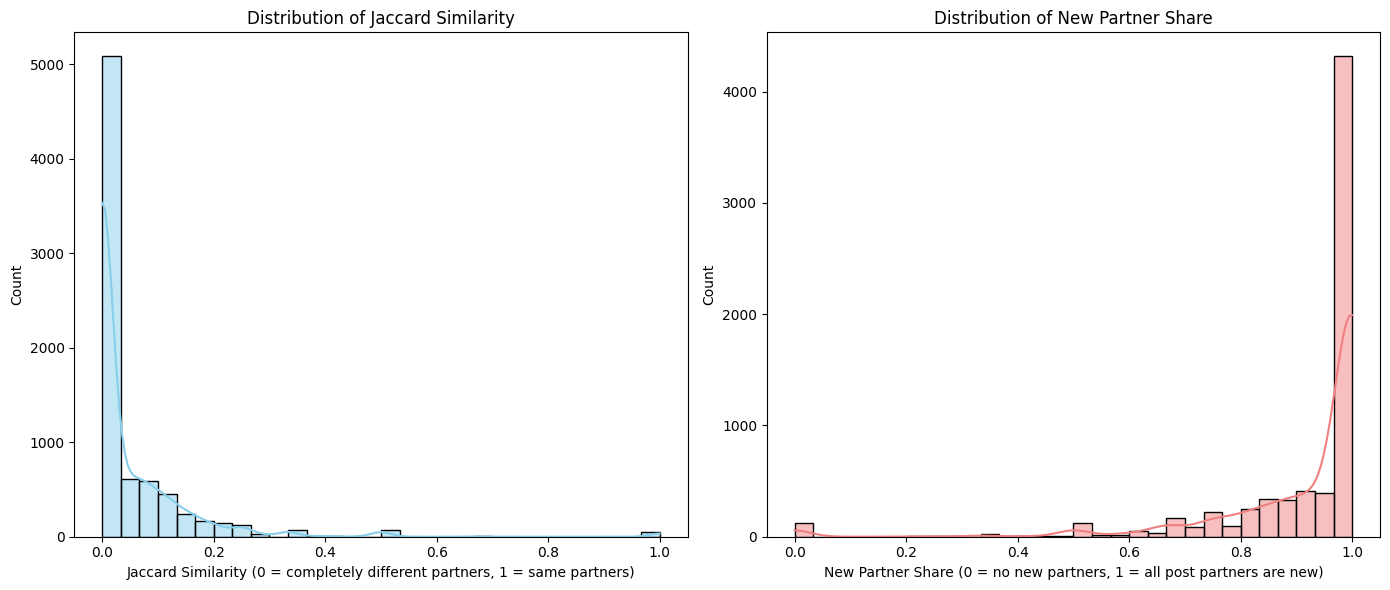

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Recalculate interaction switching metrics with tie establishment dates
switching_metrics_df = interaction_switching_metrics_tie_estab(
    interactions=interactions_df,
    tie_establishment_dates=tie_establishment_dates,
    window_days=WINDOW_DAYS
)

plt.figure(figsize=(14, 6))

# Plot Jaccard Similarity distribution
plt.subplot(1, 2, 1)
sns.histplot(switching_metrics_df['jaccard_similarity'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribution of Jaccard Similarity')
plt.xlabel('Jaccard Similarity (0 = completely different partners, 1 = same partners)')
plt.ylabel('Count')

# Plot New Partner Share distribution
plt.subplot(1, 2, 2)
sns.histplot(switching_metrics_df['new_partner_share'].dropna(), bins=30, kde=True, color='lightcoral')
plt.title('Distribution of New Partner Share')
plt.xlabel('New Partner Share (0 = no new partners, 1 = all post partners are new)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## **Robustness Checks**

| # | Change Requested | Section |
|---|---|---|
| 1 | Normalize interaction counts by time | [Time Normalization](#time_norm) |
| 2 | Apply interaction thresholds (≥2, ≥3, ≥5 etc.) | [Interaction Threshold Analysis](#threshold_analysis) |
| 3 | Analyze only high-intensity ties (top percentiles) | [High Intensity Ties](#high_intensity) |
| 4 | Analyze direction of interactions (creator → user) | [Direction of Interaction](#direction) |
| 5 | Run analysis for any user and creator-creator only | [Relationship Type](#relationship) |
| 6 | Perform robustness checks across thresholds | [Threshold Robustness](#threshold_robustness) |
| 7 | Produce clear focal graphs showing reshuffling | [Reshuffling Visualizations](#reshuffle_graphs) |

<a name="time_norm"></a>
## Time Normalization

Raw counts are not comparable across creator-tie pairs that have different pre-window lengths.
We divide each period's count by the length of that period (in days) to obtain a per-day rate,
making pre/post comparisons meaningful regardless of when the threshold crossing occurred.

In [31]:
# ① Normalise pre/post interaction counts by the length of each window
# pre_window = number of days between first observed interaction and tcross
# post_window = WINDOW_DAYS (fixed)

def normalise_intensity_by_window(intensity_by_tie, interactions_df, tie_establishment_dates, window_days=WINDOW_DAYS):
    """
    Adds per-day rate columns: intensity_pre_rate and intensity_post_rate.
    Pre-window length = days from first interaction on the tie to the tie_established_on date.
    Post-window length = window_days (fixed).
    """
    df = intensity_by_tie.copy()

    # Compute first interaction per (u,v) pair
    first_ix = (
        interactions_df
        .groupby(['source', 'target'])['time']
        .min()
        .reset_index()
        .rename(columns={'source': 'u', 'target': 'v', 'time': 'first_interaction_time'})
    )
    df = df.merge(first_ix, on=['u', 'v'], how='left', suffixes=('_orig', ''))

    # Ensure datetime
    df['tie_established_on']    = pd.to_datetime(df['tie_established_on'])
    df['first_interaction_time'] = pd.to_datetime(df['first_interaction_time'])

    # Pre-window in days (minimum 1 to avoid division by zero)
    df['pre_window_days'] = (
        (df['tie_established_on'] - df['first_interaction_time'])
        .dt.total_seconds() / 86400
    ).clip(lower=1)

    df['intensity_pre_rate']  = df['intensity_pre_tie']  / df['pre_window_days']
    df['intensity_post_rate'] = df['intensity_post_tie'] / window_days

    return df


intensity_normalised = normalise_intensity_by_window(
    intensity_by_tie_dates_agg, interactions_df, tie_establishment_dates
)

print("Normalised intensity (per-day rates):")
display(intensity_normalised[['u','v','intensity_pre_tie','intensity_post_tie',
                               'pre_window_days','intensity_pre_rate','intensity_post_rate']].head(10))

# Summary statistics
print("\nMean pre rate:",  round(intensity_normalised['intensity_pre_rate'].mean(), 4))
print("Mean post rate:", round(intensity_normalised['intensity_post_rate'].mean(), 4))

Normalised intensity (per-day rates):


,u,v,intensity_pre_tie,intensity_post_tie,pre_window_days,intensity_pre_rate,intensity_post_rate
0,54869,77381,15.0,6.0,604.712674,0.024805,0.033333
1,54878,60682,1.0,2.0,88.052431,0.011357,0.011111
2,54878,66122,2.0,0.0,6.770162,0.295414,0.000000
3,54878,87331,0.0,1.0,1.000000,0.000000,0.005556
4,54880,55642,0.0,5.0,1.000000,0.000000,0.027778
5,54880,77321,0.0,3.0,1.000000,0.000000,0.016667
6,54880,77705,3.0,0.0,2.352326,1.275333,0.000000
7,54880,81070,1.0,0.0,12.557072,0.079636,0.000000
8,54880,84104,0.0,1.0,1.000000,0.000000,0.005556
9,54880,90000,0.0,1.0,1.000000,0.000000,0.005556



Mean pre rate: 0.3206
Mean post rate: 0.0108


#### **Table Analysis**
1) **Substantial drop in interaction rates once threshold is crossed.** Mean interaction rate falls from 0.3206 before the threshold to 0.0108 after, a 97% reduction in interaction intensity.
2) **Emergence of New Interaction Partners.** Several dyads exhibit zero interactions in the pre-threshold period but positive interaction intensity afterward.
3) **Heterogeneity in Tie Strength.** Some ties display high interaction intensity before the threshold but disappear afterward. Other ties remain weak but persistent across both periods.

<a name="threshold_analysis"></a>
## Interaction Threshold Analysis
Low-activity ties (e.g. 1 interaction pre and 0 post) produce a Jaccard similarity of 0 by
construction, not because of real reshuffling. To test robustness we apply minimum interaction
thresholds (≥ 2, ≥ 3, ≥ 5) so that ties are only included when there is sufficient activity
in *both* the pre and post windows.

In [30]:
# ② / ③  Jaccard robustness under interaction thresholds

def jaccard_under_threshold(interactions, tcross, min_interactions, window_days=WINDOW_DAYS):
    """
    Compute Jaccard similarity only for creator-tie pairs where both pre AND post
    interaction counts are >= min_interactions.
    """
    crossed = tcross.index
    ev = interactions[interactions['source'].isin(crossed)].copy()
    ev = ev.merge(tcross.reset_index(), left_on='source', right_on='contact_id', how='inner')
    ev['time']   = pd.to_datetime(ev['time'])
    ev['tcross'] = pd.to_datetime(ev['tcross'])
    ev['post_end'] = ev['tcross'] + pd.Timedelta(days=window_days)
    ev['window'] = np.where(ev['time'] < ev['tcross'], 'pre', 'post')
    ev = ev[(ev['time'] < ev['tcross']) | ((ev['time'] >= ev['tcross']) & (ev['time'] <= ev['post_end']))]

    results = []
    for u, g in ev.groupby('source'):
        pre_ev  = g[g['window'] == 'pre']
        post_ev = g[g['window'] == 'post']

        # Apply threshold on interaction counts, not unique partners
        if len(pre_ev) < min_interactions or len(post_ev) < min_interactions:
            continue

        pre_partners  = set(pre_ev['target'])
        post_partners = set(post_ev['target'])
        union = pre_partners | post_partners
        intersection = pre_partners & post_partners
        jaccard = len(intersection) / len(union) if union else np.nan
        new_share = len(post_partners - pre_partners) / len(post_partners) if post_partners else np.nan

        results.append({
            'creator_id': u,
            'n_pre_events': len(pre_ev),
            'n_post_events': len(post_ev),
            'jaccard_similarity': jaccard,
            'new_partner_share': new_share
        })
    return pd.DataFrame(results)


thresholds = [2, 3, 5]
interactions_combined = build_interactions(comments, favoritings, messages, reposts)
tcross_all = compute_tcross(affiliations, creators)

threshold_results = {}
for thr in thresholds:
    df = jaccard_under_threshold(interactions_combined, tcross_all, min_interactions=thr)
    threshold_results[thr] = df
    print(f"\n--- Threshold ≥ {thr} interactions ---")
    print(f"  Creators retained : {len(df)}")
    print(f"  Mean Jaccard      : {df['jaccard_similarity'].mean():.4f}")
    print(f"  Median Jaccard    : {df['jaccard_similarity'].median():.4f}")
    print(f"  Mean new_share    : {df['new_partner_share'].mean():.4f}")


--- Threshold ≥ 2 interactions ---
  Creators retained : 6189
  Mean Jaccard      : 0.0609
  Median Jaccard    : 0.0492
  Mean new_share    : 0.8413

--- Threshold ≥ 3 interactions ---
  Creators retained : 5644
  Mean Jaccard      : 0.0640
  Median Jaccard    : 0.0536
  Mean new_share    : 0.8377

--- Threshold ≥ 5 interactions ---
  Creators retained : 4846
  Mean Jaccard      : 0.0691
  Median Jaccard    : 0.0588
  Mean new_share    : 0.8320


#### **Table Analysis**
1) **Stability of the Reshuffling Effect Across Thresholds.** Extremely low overlap in reciprocal tie interaction before and after crossing follower threshold.
2) **Consistently High Share of New Interaction Partners.** This pattern remains highly stable as the threshold increases.

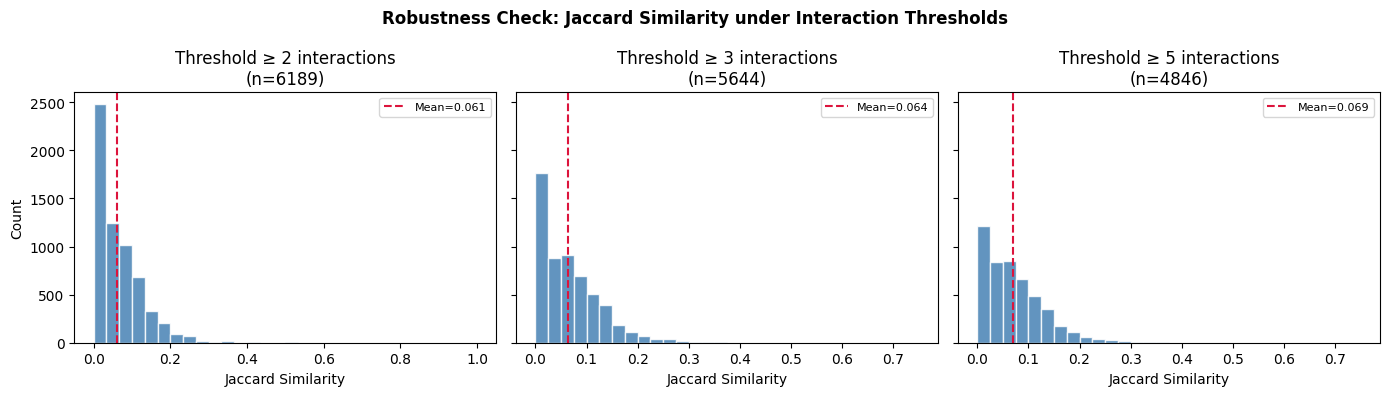

In [33]:
# Plot Jaccard distributions across thresholds
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, len(thresholds), figsize=(14, 4), sharey=True)
for ax, thr in zip(axes, thresholds):
    data = threshold_results[thr]['jaccard_similarity'].dropna()
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='crimson', linestyle='--', label=f'Mean={data.mean():.3f}')
    ax.set_title(f'Threshold ≥ {thr} interactions\n(n={len(data)})')
    ax.set_xlabel('Jaccard Similarity')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Count')
plt.suptitle('Robustness Check: Jaccard Similarity under Interaction Thresholds', fontweight='bold')
plt.tight_layout()
plt.show()

<a name="high_intensity"></a>
## High Intensity Ties

To check whether strong relationships reshuffle — not just weak ones — we restrict the
Jaccard analysis to ties in the top decile (90th percentile) of total interaction intensity.
We also expose a `top_pct` parameter to allow easy sensitivity analysis.

In [3]:
# ④  Top-intensity ties analysis

WINDOW_DAYS = 180 # Add this line to define WINDOW_DAYS within this cell

def jaccard_top_intensity_ties(interactions, tcross, tie_establishment_dates,
                                top_pct=0.10, window_days=WINDOW_DAYS):
    """
    Restrict Jaccard analysis to ties in the top `top_pct` percentile
    of total (pre + post) interaction intensity.
    """
    # Total interaction count per (u, v) edge
    edge_counts = (
        interactions
        .groupby(['source', 'target'])
        .size()
        .reset_index(name='total_interactions')
        .rename(columns={'source': 'u', 'target': 'v'})
    )
    cutoff = edge_counts['total_interactions'].quantile(1 - top_pct)
    strong_edges = edge_counts[edge_counts['total_interactions'] >= cutoff]
    print(f"Top {int(top_pct*100)}% cutoff: {cutoff:.0f} interactions | ties retained: {len(strong_edges)}")

    # Filter interactions to strong edges only
    strong_set = set(zip(strong_edges['u'], strong_edges['v']))
    ix_strong = interactions[
        interactions.apply(lambda r: (r['source'], r['target']) in strong_set, axis=1)
    ].copy()

    return jaccard_under_threshold(ix_strong, tcross, min_interactions=1, window_days=window_days)


for pct in [0.10, 0.20]:
    df_top = jaccard_top_intensity_ties(
        interactions_combined, tcross_all, tie_establishment_dates, top_pct=pct
    )
    print(f"  Mean Jaccard (top {int(pct*100)}%): {df_top['jaccard_similarity'].mean():.4f}")
    print(f"  Mean new_share   : {df_top['new_partner_share'].mean():.4f}\n")

NameError: name 'interactions_combined' is not defined

<a name="direction"></a>
## Direction of Interaction

If all observed activity flows *user → creator* (i.e. fans initiating contact),
the reshuffling signal does not represent an intentional attention shift by the focal creator.
Here we re-run the switching analysis keeping only interactions where the **focal creator
is the source** (creator-initiated interactions).

In [27]:
# ⑦  Direction-filtered interaction switching

def interaction_switching_directed(interactions, tcross, direction='creator_to_any',
                                    creator_ids=None, window_days=WINDOW_DAYS,
                                    min_pre_partners=0):
    """
    direction:
      'creator_to_any'     – focal creator is the *source* (default)
      'any_to_creator'     – focal creator is the *target*
    Only interactions matching the specified direction are counted.
    """
    crossed = tcross.index

    if direction == 'creator_to_any':
        ev = interactions[interactions['source'].isin(crossed)].copy()
        partner_col = 'target'
    else:  # any_to_creator
        ev = interactions[interactions['target'].isin(crossed)].copy()
        ev = ev.rename(columns={'source': 'target', 'target': 'source'})  # flip so groupby works
        partner_col = 'target'

    ev = ev.merge(tcross.reset_index(), left_on='source', right_on='contact_id', how='inner')
    ev['time']   = pd.to_datetime(ev['time'])
    ev['tcross'] = pd.to_datetime(ev['tcross'])
    ev['post_end'] = ev['tcross'] + pd.Timedelta(days=window_days)
    ev['window'] = np.where(ev['time'] < ev['tcross'], 'pre', 'post')
    ev = ev[(ev['time'] < ev['tcross']) | ((ev['time'] >= ev['tcross']) & (ev['time'] <= ev['post_end']))]

    results = []
    for u, g in ev.groupby('source'):
        pre_p  = set(g[g['window'] == 'pre'][partner_col])
        post_p = set(g[g['window'] == 'post'][partner_col])
        if len(pre_p) < min_pre_partners:
            continue
        union = pre_p | post_p
        jaccard = len(pre_p & post_p) / len(union) if union else np.nan
        new_share = len(post_p - pre_p) / len(post_p) if post_p else np.nan
        results.append({
            'creator_id': u, 'n_pre_partners': len(pre_p),
            'n_post_partners': len(post_p),
            'jaccard_similarity': jaccard, 'new_partner_share': new_share
        })
    return pd.DataFrame(results)

# Ensure interactions_combined and tcross_all are defined
interactions_combined = build_interactions(comments, favoritings, messages, reposts)
tcross_all = compute_tcross(affiliations, creators)

sw_creator_to_any = interaction_switching_directed(
    interactions_combined, tcross_all, direction='creator_to_any'
)
sw_any_to_creator = interaction_switching_directed(
    interactions_combined, tcross_all, direction='any_to_creator'
)

for label, df in [('Creator → Any (outgoing)', sw_creator_to_any),
                   ('Any → Creator (incoming)', sw_any_to_creator)]:
    print(f"{label}")
    print(f"  n creators       : {len(df)}")
    print(f"  Mean Jaccard     : {df['jaccard_similarity'].mean():.4f}")
    print(f"  Mean new_share   : {df['new_partner_share'].mean():.4f}\n")

Creator → Any (outgoing)
  n creators       : 8448
  Mean Jaccard     : 0.0460
  Mean new_share   : 0.8516

Any → Creator (incoming)
  n creators       : 8798
  Mean Jaccard     : 0.0381
  Mean new_share   : 0.9019



#### **Table Analysis**
1) **Outgoing Interactions: Evidence of Creator Attention Reallocation.**
    - Mean Jaccard similarity after threshold is 0.0460, indicating extremely low overlap. Only 4.6% of the partners a creator interacts with after threhold were also partners before the milestone.
    - Mean share of new partners is 0.8516, implying that approximately 85% of the users a creator interacts with after reaching the milestone are new partners.- Hence, creators intentionally redirect their attention toward different users as their popularity grows.
2) **Incoming Interactions: Even Stronger Network Turnover.**
    - Mean Jaccard similarity drops further to 0.0381, indicating that only about 3.8% of users who interact with the creator post threshold were interacting with them pre-threshold.
    - Correspondingly, the mean share of new incoming partners rises to 0.9019, meaning that over 90% of the users interacting with the creator after the milestone are new participants in the interaction network.
    - As creators become more visible within the platform, they attract attention from a much larger and more diverse set of users.

<a name="relationship"></a>
## Relationship Type

Creator-creator relationships may represent collaboration networks rather than fan interactions.
We run the switching analysis twice:
1. **Any user** – focal creator → any user with whom a reciprocal tie exists.
2. **Creator-creator only** – focal creator → *other creators* only.

In [28]:
# ⑧  Any-user version vs. creator-creator-only version

def interaction_switching_creator_creator(interactions, tcross, creator_ids,
                                           window_days=WINDOW_DAYS, min_pre_partners=0):
    """
    Like interaction_switching_directed but restricts targets to other creators only.
    """
    crossed = tcross.index
    creator_set = set(creator_ids)

    ev = interactions[
        interactions['source'].isin(crossed) &
        interactions['target'].isin(creator_set)
    ].copy()

    ev = ev.merge(tcross.reset_index(), left_on='source', right_on='contact_id', how='inner')
    ev['time']   = pd.to_datetime(ev['time'])
    ev['tcross'] = pd.to_datetime(ev['tcross'])
    ev['post_end'] = ev['tcross'] + pd.Timedelta(days=window_days)
    ev['window'] = np.where(ev['time'] < ev['tcross'], 'pre', 'post')
    ev = ev[(ev['time'] < ev['tcross']) | ((ev['time'] >= ev['tcross']) & (ev['time'] <= ev['post_end']))]

    results = []
    for u, g in ev.groupby('source'):
        pre_p  = set(g[g['window'] == 'pre']['target'])
        post_p = set(g[g['window'] == 'post']['target'])
        if len(pre_p) < min_pre_partners:
            continue
        union = pre_p | post_p
        jaccard = len(pre_p & post_p) / len(union) if union else np.nan
        new_share = len(post_p - pre_p) / len(post_p) if post_p else np.nan
        results.append({
            'creator_id': u, 'n_pre_partners': len(pre_p),
            'n_post_partners': len(post_p),
            'jaccard_similarity': jaccard, 'new_partner_share': new_share
        })
    return pd.DataFrame(results)


sw_any_user       = interaction_switching_directed(interactions_combined, tcross_all,
                                                    direction='creator_to_any')
sw_creator_creator = interaction_switching_creator_creator(
    interactions_combined, tcross_all, creator_ids=creators
)

comparison = pd.DataFrame({
    'Version'      : ['Any user', 'Creator-creator only'],
    'n_creators'   : [len(sw_any_user), len(sw_creator_creator)],
    'Mean Jaccard' : [sw_any_user['jaccard_similarity'].mean(),
                      sw_creator_creator['jaccard_similarity'].mean()],
    'Mean new_share': [sw_any_user['new_partner_share'].mean(),
                       sw_creator_creator['new_partner_share'].mean()]
})
display(comparison)

,Version,n_creators,Mean Jaccard,Mean new_share
0,Any user,8448,0.046030,0.851634
1,Creator-creator only,5930,0.061871,0.786382


#### **Table Analysis**
1) **Strong Reshuffling When Considering All Users.**
    - Only about 4.6% of users interacting with a creator after the milestone were also interaction partners before the milestone.
    - Approximately 85% of interaction partners after the milestone are new users.
2) **Reshuffling Is Weaker but Still Strong Among Creators.**
    - The mean Jaccard similarity increases slightly to 0.0619, while the mean share of new partners declines to 0.7864.
    - Although the reshuffling effect becomes somewhat weaker under this restriction, the magnitude of network turnover remains substantial.

<a name="threshold_robustness"></a>
## Threshold Robustness

We compile results across all robustness dimensions into a single summary table,
showing that the reshuffling effect (high `new_partner_share`, low `jaccard_similarity`)
is consistent across:
- Interaction thresholds (≥ 2, 3, 5)
- Tie-intensity thresholds (top 10%, top 20%)
- Direction of interaction (creator → any, any → creator)
- Relationship type (any user, creator-creator only)

In [31]:
# ⑨  Consolidated robustness table

rows = []

# Interaction thresholds
for thr in [2, 3, 5]:
    df = threshold_results[thr]
    rows.append({
        'Dimension': 'Interaction threshold',
        'Specification': f'>= {thr} events',
        'n_creators': len(df),
        'Mean Jaccard': round(df['jaccard_similarity'].mean(), 4),
        'Mean new_share': round(df['new_partner_share'].mean(), 4)
    })

# Direction
for label, df in [('Creator → Any', sw_creator_to_any), ('Any → Creator', sw_any_to_creator)]:
    rows.append({
        'Dimension': 'Direction of interaction',
        'Specification': label,
        'n_creators': len(df),
        'Mean Jaccard': round(df['jaccard_similarity'].mean(), 4),
        'Mean new_share': round(df['new_partner_share'].mean(), 4)
    })

# Relationship type
for label, df in [('Any user', sw_any_user), ('Creator-creator only', sw_creator_creator)]:
    rows.append({
        'Dimension': 'Relationship type',
        'Specification': label,
        'n_creators': len(df),
        'Mean Jaccard': round(df['jaccard_similarity'].mean(), 4),
        'Mean new_share': round(df['new_partner_share'].mean(), 4)
    })

robustness_table = pd.DataFrame(rows)
display(robustness_table.to_string(index=False))

'               Dimension        Specification  n_creators  Mean Jaccard  Mean new_share\n   Interaction threshold          >= 2 events        6189        0.0609          0.8413\n   Interaction threshold          >= 3 events        5644        0.0640          0.8377\n   Interaction threshold          >= 5 events        4846        0.0691          0.8320\nDirection of interaction        Creator → Any        8448        0.0460          0.8516\nDirection of interaction        Any → Creator        8798        0.0381          0.9019\n       Relationship type             Any user        8448        0.0460          0.8516\n       Relationship type Creator-creator only        5930        0.0619          0.7864'

#### **Table Analysis**
1) **Interaction Threshold Robustness.**
    - Increasing the threshold slightly increases Jaccard similarity (0.0609 → 0.0691).
    - The share of new partners slightly decreases (0.8413 → 0.8320).
2) **Direction of Interaction.**
  - Creator outgoing interactions.
    - Around 4.6% overlap between pre- and post-partners.
    - About 85% of partners are new.
    - Creators themselves shift attention to new users after threshold.
  - Incoming interactions.
    - Overlap falls even further (3.8%).
    - The share of new partners rises to ~90%.
    - As creators grow, many new users begin interacting with them, dramatically reshaping their incoming network.
3) Relationship Type (Audience vs Creator Network)
  - All users
    - Only 4.6% overlap.
    - About 85% new partners.
    - Large audience turnover as creators attract new listeners.
  - Creator–creator relationships
    - Overlap increases slightly to 6.2%.
    - New partners drop to ~79%.
    - Even within the creator network, reshuffling remains substantial.
4) Overall Conclusion
Across all specifications, the same core pattern appears:
  - Jaccard similarity remains extremely low (≈4–7%)
  - The share of new partners remains extremely high (≈78–90%)

*Creators interaction networks change dramatically after crossing the follower milestone.*

<a name="reshuffle_graphs"></a>
## Reshuffling Visualizations

Before complex models, intuitive focal-network plots help communicate the reshuffling mechanism.
For a focal creator we draw the ego network of interaction partners:
- **Blue nodes** – pre-crossing partners (retained post-crossing = darker shade)
- **Orange nodes** – new post-crossing partners
- The focal creator node sits in the centre.

We show three representative focal creators: one with strong reshuffling, one with moderate,
and one with stable ties.

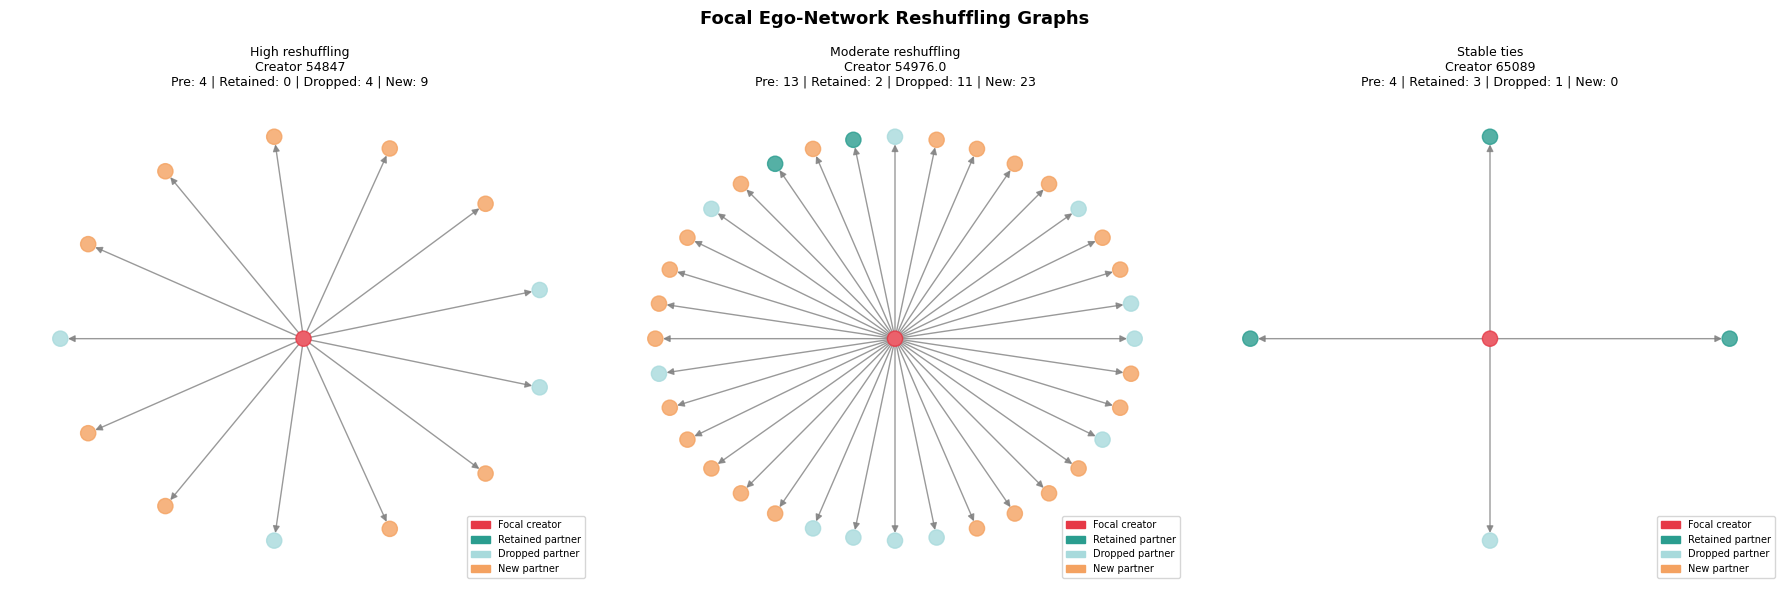

In [33]:
# ⑩  Focal ego-network reshuffling graphs
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def focal_reshuffling_graph(creator_id, interactions, tcross, window_days=WINDOW_DAYS, ax=None):
    """
    Draw the ego network of `creator_id` showing pre vs. post interaction partners.
    """
    tcross_series = pd.to_datetime(tcross)
    if creator_id not in tcross_series.index:
        print(f"{creator_id} not in tcross index")
        return

    t = tcross_series.loc[creator_id]
    post_end = t + pd.Timedelta(days=window_days)

    ev = interactions[interactions['source'] == creator_id].copy()
    ev['time'] = pd.to_datetime(ev['time'])

    pre_partners  = set(ev[ev['time'] < t]['target'])
    post_partners = set(ev[(ev['time'] >= t) & (ev['time'] <= post_end)]['target'])
    retained = pre_partners & post_partners
    dropped  = pre_partners - post_partners
    new      = post_partners - pre_partners

    G = nx.DiGraph()
    G.add_node(creator_id, kind='focal')
    for p in retained: G.add_node(p, kind='retained')
    for p in dropped:  G.add_node(p, kind='dropped')
    for p in new:      G.add_node(p, kind='new')
    for p in pre_partners | post_partners:
        G.add_edge(creator_id, p)

    color_map = {'focal': '#e63946', 'retained': '#2a9d8f',
                 'dropped': '#a8dadc', 'new': '#f4a261'}
    node_colors = [color_map[G.nodes[n]['kind']] for n in G.nodes]

    pos = nx.shell_layout(G, nlist=[[creator_id],
                                     list(pre_partners | post_partners)])
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))

    nx.draw_networkx(G, pos=pos, ax=ax, node_color=node_colors,
                     node_size=120, font_size=6, arrows=True,
                     edge_color='grey', alpha=0.8, with_labels=False)
    ax.set_title(
        f"Creator {creator_id}\n"
        f"Pre: {len(pre_partners)} | Retained: {len(retained)} | "
        f"Dropped: {len(dropped)} | New: {len(new)}",
        fontsize=9
    )
    ax.axis('off')

    legend_patches = [
        mpatches.Patch(color='#e63946', label='Focal creator'),
        mpatches.Patch(color='#2a9d8f', label='Retained partner'),
        mpatches.Patch(color='#a8dadc', label='Dropped partner'),
        mpatches.Patch(color='#f4a261', label='New partner'),
    ]
    ax.legend(handles=legend_patches, fontsize=7, loc='lower right')


# Pick three illustrative creators from the switching metrics results
sw_all = interaction_switching_directed(interactions_combined, tcross_all,
                                         direction='creator_to_any')
sw_all_clean = sw_all.dropna(subset=['jaccard_similarity']).query('n_pre_partners >= 3 and n_post_partners >= 3')

# High reshuffling (low Jaccard)
high_reshuffle = sw_all_clean.nsmallest(1, 'jaccard_similarity')['creator_id'].values[0]
# Moderate reshuffling (near median Jaccard)
median_j = sw_all_clean['jaccard_similarity'].median()
moderate_reshuffle = sw_all_clean.iloc[(sw_all_clean['jaccard_similarity'] - median_j).abs().argsort().iloc[0]]['creator_id']
# Stable ties (high Jaccard)
stable = sw_all_clean.nlargest(1, 'jaccard_similarity')['creator_id'].values[0]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, cid, label in zip(axes,
                           [high_reshuffle, moderate_reshuffle, stable],
                           ['High reshuffling', 'Moderate reshuffling', 'Stable ties']):
    focal_reshuffling_graph(cid, interactions_combined, tcross_all, ax=ax)
    ax.set_title(f"{label}\n" + ax.get_title(), fontsize=9)

plt.suptitle('Focal Ego-Network Reshuffling Graphs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()